<a href="https://colab.research.google.com/github/Deepika-J2106/sentiment-analysis-nlp/blob/main/Sentimentanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset (1).csv


In [21]:
import pandas as pd
df = pd.read_csv('IMDB Dataset.csv')
df.info()
print(df['sentiment'].value_counts())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [22]:
print(df['review'][0])
print('Length of first element:',len(df['review'][0]))

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

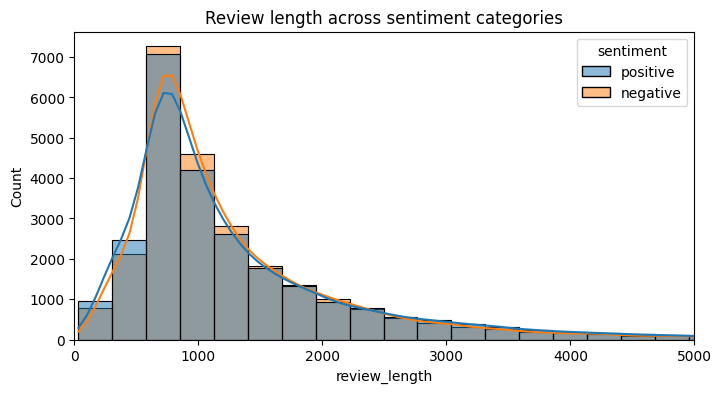

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
df["review_length"] = df['review'].apply(len)
plt.figure(figsize = (8,4))
sns.histplot(data = df, x = "review_length", hue = "sentiment" , bins = 50, kde = True)
plt.title("Review length across sentiment categories")
plt.xlim(0,5000)
plt.show()

In [24]:
from collections import Counter
import re
def get_top_words(text_series,n=15):
  all_words = ' '.join(text_series).lower()
  words = re.findall(r'\b[a-z]+\b', all_words)
  return Counter(words).most_common(n)

print("Top words of positive reviews are: ", get_top_words(df[df['sentiment'] == 'positive']['review']))
print("Top words of negative reviews are: ", get_top_words(df[df['sentiment'] == 'negative']['review']))


Top words of positive reviews are:  [('the', 341281), ('and', 176634), ('a', 164323), ('of', 152105), ('to', 131322), ('is', 111830), ('in', 99250), ('br', 97954), ('it', 95133), ('i', 81997), ('this', 69648), ('that', 69593), ('s', 64675), ('as', 51106), ('with', 45718)]
Top words of negative reviews are:  [('the', 326712), ('a', 158647), ('and', 147807), ('of', 137305), ('to', 136802), ('br', 103997), ('is', 99252), ('it', 95724), ('i', 93636), ('in', 87531), ('this', 81354), ('that', 74286), ('s', 60333), ('was', 52269), ('movie', 50117)]


In [25]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
  text = re.sub(r'<.>*?>',' ', text)
  text = text.lower()
  text = re.sub(r'[^a-z\s]','', text)
  words = text.split()
  words = [w for w in words if w not in stop_words]
  return ' '.join(words)

df['cleaned_review'] = df['review'].apply(clean_text)
print(df[['review','cleaned_review']].head(2))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   

                                      cleaned_review  
0  one reviewers mentioned watching oz episode yo...  
1  wonderful little production br br filming tech...  


In [26]:
print('Top words in cleaned positive review: ', df[df["sentiment"] == 'positive']["cleaned_review"])
print('Top words in cleaned negative review: ', df[df["sentiment"] == 'negative']["cleaned_review"])

Top words in cleaned positive review:  0        one reviewers mentioned watching oz episode yo...
1        wonderful little production br br filming tech...
2        thought wonderful way spend time hot summer we...
4        petter matteis love time money visually stunni...
5        probably alltime favorite movie story selfless...
                               ...                        
49983    loved fan original series always wondered back...
49985    imaginary heroes clearly best film year comple...
49989    got one weeks ago love modern light filled tru...
49992    john garfield plays marine blinded grenade fig...
49995    thought movie right good job wasnt creative or...
Name: cleaned_review, Length: 25000, dtype: object
Top words in cleaned negative review:  3        basically theres family little boy jake thinks...
7        show amazing fresh innovative idea first aired...
8        encouraged positive comments film looking forw...
10       phil alien one quirky films humour b

In [27]:
from sklearn.model_selection import train_test_split
X = df['cleaned_review']
y = df['sentiment'].map({'positive' : 1, 'negative' : 0})
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y)
print("Train size:" , X_train.shape)
print("Test size: ", X_test.shape)

Train size: (40000,)
Test size:  (10000,)


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features = 5000, min_df = 5, max_df = 0.8)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.fit_transform(X_test)

print("Training matrix shape: ", X_train_tfidf.shape)
print("Testing matrix shape: ", X_test_tfidf.shape)

Training matrix shape:  (40000, 5000)
Testing matrix shape:  (10000, 5000)


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train_tfidf, y_train)

lr_preds = lr.predict(X_test_tfidf)
print("Logistic Regression Results: ")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(f"F1-score: {f1_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds, target_names=['Negative', 'Positive']))

Logistic Regression Results: 
Accuracy: 0.5455
F1-score: 0.5661
              precision    recall  f1-score   support

    Negative       0.55      0.50      0.52      5000
    Positive       0.54      0.59      0.57      5000

    accuracy                           0.55     10000
   macro avg       0.55      0.55      0.54     10000
weighted avg       0.55      0.55      0.54     10000



In [30]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

nb_preds = nb.predict(X_test_tfidf)
print("Naive Bayes Results:")
print(f"Accuracy : {accuracy_score(y_test,nb_preds):4f}")
print(f"F1-score: {f1_score(y_test, nb_preds):.4f}")
print(classification_report(y_test, nb_preds, target_names=['Negative', 'Positive']))

Naive Bayes Results:
Accuracy : 0.539000
F1-score: 0.6330
              precision    recall  f1-score   support

    Negative       0.58      0.28      0.38      5000
    Positive       0.53      0.80      0.63      5000

    accuracy                           0.54     10000
   macro avg       0.55      0.54      0.51     10000
weighted avg       0.55      0.54      0.51     10000



In [31]:
results = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, lr_preds),
        'F1': f1_score(y_test, lr_preds)
    },
    'Naive Bayes': {
        'Accuracy': accuracy_score(y_test, nb_preds),
        'F1': f1_score(y_test, nb_preds)
    }
}

print(f"{'Model':<22} {'Accuracy':<12} {'F1-Score':<12}")
print("-" * 46)
for name, metrics in results.items():
    print(f"{name:<22} {metrics['Accuracy']:<12.4f} {metrics['F1']:<12.4f}")

Model                  Accuracy     F1-Score    
----------------------------------------------
Logistic Regression    0.5455       0.5661      
Naive Bayes            0.5390       0.6330      


In [32]:
print(df['sentiment'].unique())
print(y_train.value_counts())
print(y_test.value_counts())

['positive' 'negative']
sentiment
1    20000
0    20000
Name: count, dtype: int64
sentiment
0    5000
1    5000
Name: count, dtype: int64


In [33]:
print(df['cleaned_review'].iloc[0][:200])
print(df['cleaned_review'].isnull().sum())
print((df['cleaned_review'] == '').sum())

one reviewers mentioned watching oz episode youll hooked right exactly happened mebr br first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid sho
0
0


In [34]:
print(X_train_tfidf.shape)
print(X_train_tfidf.sum())
print(tfidf.get_feature_names_out()[:20])

(40000, 5000)
303558.72126921423
['aaron' 'abandoned' 'abc' 'abilities' 'ability' 'able' 'aboutbr'
 'absence' 'absent' 'absolute' 'absolutely' 'absurd' 'abuse' 'abused'
 'abusive' 'abysmal' 'academy' 'accent' 'accents' 'accept']


In [35]:
print(len(X_train), X_train_tfidf.shape[0], len(y_train))

40000 40000 40000


In [36]:
# Check if the model actually learned anything
print("LR classes:", lr.classes_)
print("LR coefficients shape:", lr.coef_.shape)

# Check prediction distribution
import numpy as np
print("Predicted value counts:", np.unique(lr_preds, return_counts=True))
print("Actual value counts:", np.unique(y_test, return_counts=True))

# Check a few actual predictions vs truth
print("\nFirst 10 predictions:", lr_preds[:10])
print("First 10 actual:     ", y_test.values[:10])

LR classes: [0 1]
LR coefficients shape: (1, 5000)
Predicted value counts: (array([0, 1]), array([4525, 5475]))
Actual value counts: (array([0, 1]), array([5000, 5000]))

First 10 predictions: [1 0 1 0 0 1 1 0 1 1]
First 10 actual:      [0 0 1 0 0 0 0 0 0 0]


In [37]:
print(type(X_train_tfidf))   # should be <class 'scipy.sparse._csr.csr_matrix'>
print(type(y_train))          # should be <class 'pandas.core.series.Series'>
print(type(lr_preds))         # should be <class 'numpy.ndarray'>

<class 'scipy.sparse._csr.csr_matrix'>
<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>


In [38]:
# Re-run train_test_split and TF-IDF fitting fresh, right now, in one go
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['cleaned_review']
y = df['sentiment'].map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score
print("Fresh accuracy:", accuracy_score(y_test, lr_preds))

Fresh accuracy: 0.8894


=== Logistic Regression ===
Accuracy: 0.8894
F1-Score: 0.8903
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



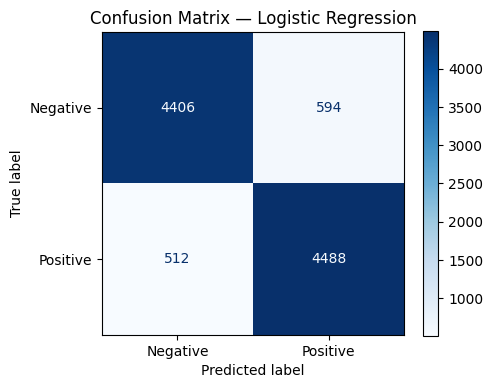

In [39]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

lr_preds = lr.predict(X_test_tfidf)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(f"F1-Score: {f1_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds, target_names=['Negative', 'Positive']))

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_preds,
    display_labels=['Negative', 'Positive'],
    cmap='Blues', ax=ax)
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_preds = nb.predict(X_test_tfidf)

print("=== Naive Bayes ===")
print(f"Accuracy: {accuracy_score(y_test, nb_preds):.4f}")
print(f"F1-Score: {f1_score(y_test, nb_preds):.4f}")
print(classification_report(y_test, nb_preds, target_names=['Negative', 'Positive']))

=== Naive Bayes ===
Accuracy: 0.8537
F1-Score: 0.8546
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.85      5000
    Positive       0.85      0.86      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [41]:
print(f"\n{'Model':<25} {'Accuracy':<12} {'F1-Score'}")
print("-" * 50)
print(f"{'Logistic Regression':<25} {accuracy_score(y_test, lr_preds):<12.4f} {f1_score(y_test, lr_preds):.4f}")
print(f"{'Naive Bayes':<25} {accuracy_score(y_test, nb_preds):<12.4f} {f1_score(y_test, nb_preds):.4f}")


Model                     Accuracy     F1-Score
--------------------------------------------------
Logistic Regression       0.8894       0.8903
Naive Bayes               0.8537       0.8546


Top POSITIVE words:
     word  coefficient
    great     7.134510
excellent     6.727581
  perfect     5.314306
  amazing     4.971618
     best     4.844144
    loved     4.606416
hilarious     4.520590
wonderful     4.465621
 favorite     4.282598
  enjoyed     4.268354
brilliant     3.983654
   superb     3.932757
      fun     3.817467
enjoyable     3.815918
   highly     3.761621

Top NEGATIVE words:
          word  coefficient
         worst   -10.294478
         waste    -8.049708
         awful    -7.592446
           bad    -7.441743
        boring    -6.081770
          poor    -5.574118
      terrible    -5.504286
        poorly    -5.296607
       nothing    -5.279267
          dull    -5.153683
         worse    -5.070789
      horrible    -5.033124
         fails    -4.809340
 disappointing    -4.582885
disappointment    -4.446047


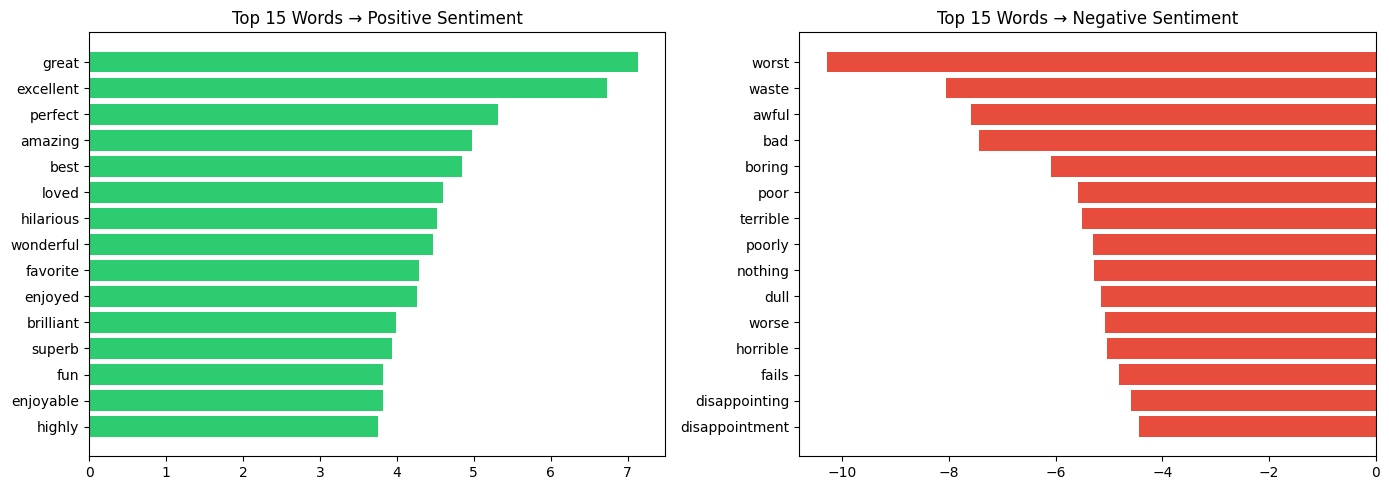

In [42]:
import numpy as np
import pandas as pd

feature_names = tfidf.get_feature_names_out()
coefficients = lr.coef_[0]

# Top 15 words pushing toward POSITIVE sentiment
top_positive_idx = np.argsort(coefficients)[-15:][::-1]
top_positive = pd.DataFrame({
    'word': feature_names[top_positive_idx],
    'coefficient': coefficients[top_positive_idx]
})

# Top 15 words pushing toward NEGATIVE sentiment
top_negative_idx = np.argsort(coefficients)[:15]
top_negative = pd.DataFrame({
    'word': feature_names[top_negative_idx],
    'coefficient': coefficients[top_negative_idx]
})

print("Top POSITIVE words:")
print(top_positive.to_string(index=False))
print("\nTop NEGATIVE words:")
print(top_negative.to_string(index=False))

# Plot both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(top_positive['word'], top_positive['coefficient'], color='#2ecc71')
ax1.set_title('Top 15 Words → Positive Sentiment')
ax1.invert_yaxis()

ax2.barh(top_negative['word'], top_negative['coefficient'], color='#e74c3c')
ax2.set_title('Top 15 Words → Negative Sentiment')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('top_words_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
!pip install transformers -q

from transformers import pipeline

# Load pretrained sentiment pipeline (DistilBERT)
print("Loading DistilBERT pipeline...")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english")

# Test on 5 sample reviews from your test set
sample_reviews = X_test.iloc[:5].tolist()
sample_labels = y_test.iloc[:5].tolist()

print("\n=== DistilBERT Predictions on 5 samples ===")
for i, review in enumerate(sample_reviews):
    result = sentiment_pipeline(review[:512])[0]  # BERT has 512 token limit
    predicted = 1 if result['label'] == 'POSITIVE' else 0
    actual = sample_labels[i]
    match = "✅" if predicted == actual else "❌"
    print(f"Sample {i+1}: Predicted={result['label']} ({result['score']:.2%}) | Actual={'POS' if actual==1 else 'NEG'} {match}")

Loading DistilBERT pipeline...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]


=== DistilBERT Predictions on 5 samples ===
Sample 1: Predicted=NEGATIVE (99.52%) | Actual=NEG ✅
Sample 2: Predicted=POSITIVE (87.11%) | Actual=NEG ❌
Sample 3: Predicted=NEGATIVE (94.89%) | Actual=POS ❌
Sample 4: Predicted=NEGATIVE (95.11%) | Actual=NEG ✅
Sample 5: Predicted=NEGATIVE (99.82%) | Actual=NEG ✅


## Classical NLP vs Transformer — Trade-off Analysis

| | TF-IDF + Logistic Regression | DistilBERT |
|---|---|---|
| Accuracy (IMDB) | 88.94% | ~93% (benchmark) |
| Training time | < 30 seconds | Hours (without GPU) |
| Inference speed | Milliseconds | ~100ms per sample |
| Interpretability | High (coefficient weights) | Low (black box) |
| Compute cost | Minimal (CPU) | High (GPU recommended) |
| Best for | Production at scale, low latency | Highest accuracy, contextual understanding |

**Conclusion:** For a production churn or review classification system where
latency and cost matter, TF-IDF + Logistic Regression at 88.94% accuracy is
often the right engineering choice. DistilBERT is the right choice when accuracy
is the top priority and compute budget is available.

In [45]:
# Images to upload to GitHub images/ folder:
# - confusion_matrix_lr.png
# - top_words_by_sentiment.png
# (download from Colab files panel → upload to images/ on GitHub)

print("Project complete. Images to upload:")
print("1. confusion_matrix_lr.png")
print("2. top_words_by_sentiment.png")

Project complete. Images to upload:
1. confusion_matrix_lr.png
2. top_words_by_sentiment.png
